This note illustrates the decomposition of Magnetic Resonance Spetroscopy signals via Fast Padé Transform.  This might be rather complex, especially if you did not study advanced mathematics, therefore more details/edits upcoming.  The core reference is [Quantum-Mechanical Signal Processing and Spectral Analysis](https://www.taylorfrancis.com/books/mono/10.1201/9780429146534/quantum-mechanical-signal-processing-spectral-analysis-dzevad-belkic).

# Preliminaries

In [ ]:
import os

In [ ]:
os.chdir(path=os.getcwd())
os.getcwd()

'/content'

<br>

## Libraries

Importing libraries.

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Libraries

%matplotlib inline

import logging
import collections
import sys
import typing

import time
import datetime
import math

import pathlib
import requests
import json

import dask
import dask.dataframe as dd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import numpy as np
import pandas as pd
import scipy

import tensorflow as tf
import sklearn.preprocessing
import sklearn.model_selection

import keras
import keras.wrappers

<br>

## Settings

The random numbers generation settings.

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Settings

RANDOM_SEED = 35
rng = np.random.default_rng(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

<br>

## Graphing

The set-up for graphing.

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Graphing

matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['text.usetex'] = False

sns.set(font_scale=1)
sns.set_style('dark')

plt.rcParams['figure.constrained_layout.use'] = False

<br>

## Logging

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Logging

logging.basicConfig(level=logging.INFO,
                    format='\n%(message)s\n%(asctime)s.%(msecs)03d',
                    datefmt='%Y-%m-%d %H:%M:%S', force=True)
logger = logging.getLogger(__name__)

p_logger = logging.getLogger('matplotlib')
p_logger.setLevel(logging.WARNING)

<br>
<br>

# Algebra: A Brief Review

## Solving a system of equations

In relation to a system of equations

$A\mathbf{x} = \mathbf{b}$

<br>

In [ ]:
A = np.array([[1, 3, 5], [2, 5, 1], [2, 3, 8]])
b = np.array([[10], [8], [3]])

In [ ]:
logger.info('%s\n%s', A, b)


[[1 3 5]
 [2 5 1]
 [2 3 8]]
[[10]
 [ 8]
 [ 3]]
2026-08-25 11:16:19.853


<br>

$\mathbf{x}$ is determinable **via**

In [ ]:
scipy.linalg.solve(A, b)

array([[-9.28],
       [ 5.16],
       [ 0.76]])

<br>

**or**

In [ ]:
inverse = scipy.linalg.inv(A)
inverse.dot(b)

array([[-9.28],
       [ 5.16],
       [ 0.76]])

<br>
<br>

If $A$ is a non-square matrix &Rarr;

In [ ]:
(scipy.linalg.pinv(A)).dot(b)

array([[-9.28],
       [ 5.16],
       [ 0.76]])

<br>
<br>

## Toeplitz

This illustrates a Toeplitz matrix; the vector $\mathbf{x}$ is converted to Toeplitz matrix $T$.

In [ ]:
x = np.array([1, 2, 3, 4, 5, 6])
T = scipy.linalg.toeplitz(c=x[0]*np.identity(3)[:,0], r=x[:3])

logger.info('x:%s\nT:%s\n', x, T)


x:[1 2 3 4 5 6]
T:[[1. 2. 3.]
 [0. 1. 2.]
 [0. 0. 1.]]

2026-08-25 11:16:23.260


<br>
<br>

# Data

## Experiment Details

The signal in focus was acquired via a hospital's magnetic resonance imaging machine used for scanning patients.  This signal was acquired from an object, phantom, placed in the machine.  Upcoming examples will include signals courtesy of volunteers; unidentifiable.

* hydrogen: $\small{MHzT^{-1}}$
* tesla: $\small{T}$
* magnet: $\small{MHz}$ &Larr; excitation frequency
* shift: parts per million (p.p.m.)

In [ ]:
hydrogen = 42.58
tesla = 1.5
magnet = hydrogen * tesla
tau = 0.0004
steps = 2048
shift = 4.839
region = 'negative'

In [ ]:
l_boundary = 0
u_boundary = 5

In [ ]:
times = np.linspace(start=0, stop=tau*(steps - 1), num=steps)
points = np.linspace(start=-steps/2, stop=(steps/2 - 1), num=steps)

In [ ]:
V = points/(steps * tau)
ppm = V/magnet

In [ ]:
times.max()

np.float64(0.8188000000000001)

<br>
<br>

## Read

The data.  The data file's name encodes 2 signal acquisition details; TE denotes *echo time*, herein 35 seconds; NSA denotes *number of signal averages*.  Note, as the number of signal averages is increased, the signal to noise ratio improves; ref. [Issues of spectral quality in clinical $^{1}$H-magnetic resonance spectroscopy and a gallery of artifacts](https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/10.1002/nbm.891).

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Reading the data

uri = os.path.join(os.getcwd(), 'TE35NSA128.txt')

try:
    data = pd.read_table(filepath_or_buffer=uri, header=None, encoding='utf-8')
except OSError as err:
    raise err from err

data = data.copy().set_axis(labels=['real', 'imaginary', 'spectrum', 'machine'], axis=1)

In [ ]:
logger.info(data.head())


      real  imaginary  spectrum   machine
0  15.9260    0.72086   0.47523   3.46510
1  14.7900   -4.21690   5.74580  16.50000
2  12.4370   -8.00370  -3.34530   8.08850
3   8.4422  -11.74100   6.65890  13.23100
4   4.2609  -12.86100   7.35160  -0.39958
2026-08-25 11:17:13.205


<br>
<br>

## Spectrum

(0.0, 5.0)

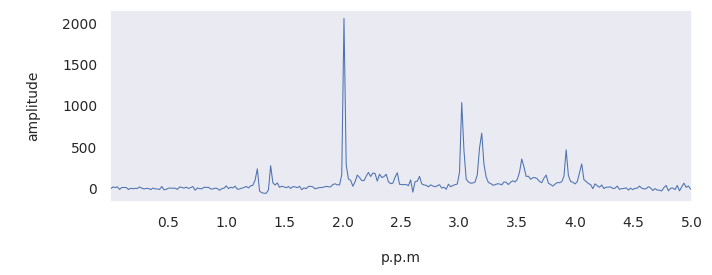

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The Signal: Spectrum

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)


fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=(ppm + shift), y=data['spectrum'], size=0.85, legend=False)

handle.set_xticks(ticks=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

handle.set_xlabel('\np.p.m', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim(0, 5)

<br>
<br>

## Series

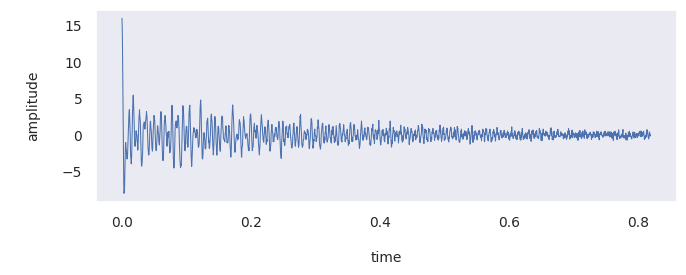

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The Signal: Series

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)


fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=times, y=data['real'], size=0.85, legend=False)

handle.set_xlabel('\ntime', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});


<br>
<br>

# Rational Functions

This section determines 2 complementary rational function approximations of the time series signal; FPT$^{+}$ & FPT$^{-}$.

In [ ]:
N = data.shape[0]
K = int(0.5 * N)
M = N - 1 - K
Y = data['real'].values + 1j*data['imaginary'].values

In [ ]:
logger.info('N: %s, K: %s, M: %s, Y:%s', N, K, M, Y.shape[0])


N: 2048, K: 1024, M: 1023, Y:2048
2026-08-25 11:18:06.169


<br>

## FPT$^{+}$

$\large\frac{A^{^{+}}_{K}}{B^{^{+}}_{K}}$

HB = V$_{_{0, \ldots, M \: | \: 1}}$

* H: a Hankel matrix, the system of equations coefficients
* B: denominator coefficients, the system of equations variables
* V: the constant terms of a system of equations

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown FPT$^{+}$

class FPTP:

    def __init__(self, sequence: np.ndarray) -> None:

        self.__sequence = sequence

    def __get_denominator(self) -> np.ndarray:

        V = self.__sequence[:(M + 1)]
        c = self.__sequence[1:(M + 2)]
        r = self.__sequence[(M + 1):(M + K + 1)]
        H = scipy.linalg.hankel(c=c, r=r)

        inverse = scipy.linalg.pinv(H)
        B = inverse.dot(-V)

        return B

    def __get_numerator(self, B: np.ndarray):

        sequence = self.__sequence[:K]
        T = scipy.linalg.toeplitz(
            c=sequence[0]*np.identity(sequence.shape[0])[:,0],
            r=sequence)

        A = T.dot(B)

        return A

    def __call__(self):

        B = self.__get_denominator()
        A = self.__get_numerator(B=B)

        return A, B


In [ ]:
fptp = FPTP(sequence=Y)
p_numerator, p_denominator = fptp()

In [ ]:
logger.info('The numerator coefficients of the rational function:\n\n%s\n\n%s', p_numerator, p_numerator.shape)


The numerator coefficients of the rational function:

[-11.87727566-12.84987878j -11.97288386-21.4786967j
   6.8938419  +0.57977358j ...   2.65554129 +8.26917421j
  -2.04157124+13.49373859j   4.70662712+15.79678261j]

(1024,)
2026-08-25 11:18:32.998


In [ ]:
logger.info('The denominator coefficients of the rational function:\n\n%s\n\n%s', p_denominator, p_denominator.shape)


The denominator coefficients of the rational function:

[-0.39499587+0.16796689j -0.50986667-0.14499953j -0.43098557+0.09807689j
 ...  0.02947559-0.31676488j -0.69944197+0.06203563j
  0.33973085+0.97650912j]

(1024,)
2026-08-25 11:18:34.969


<br>
<br>

## FPT$^{-}$

$\large\frac{A^{^{-}}_{K}}{B^{^{-}}_{K}}$

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown FPT$^{-}$

class FPTN:

    def __init__(self, sequence: np.ndarray) -> None:

        self.__sequence = sequence
        self.__beta = 1

    def __get_denominator(self):
        """

        V = self.__sequence[(K + 1):(K + M + 1)]
        c = self.__sequence[K:(K + M)]
        B = inverse.dot(-self.__beta * V)
        """

        # Constant Terms
        V = self.__sequence[K:(K + M + 1)]

        # Hankel
        c = self.__sequence[(K - 1):(K + M)]
        r = np.flipud(c)
        H = scipy.linalg.hankel(c=c, r=r)

        # Hence, the denominator coefficients
        inverse = scipy.linalg.pinv(H)
        B = inverse.dot(-V)

        return B

    def __get_numerator(self, B: np.ndarray):

        # Toeplitz
        c = self.__sequence[:K]
        r = c[0]*np.identity(c.shape[0])[:,0]
        T = scipy.linalg.toeplitz(c=c, r=r)

        # Hence, the numerator coefficients
        A = T.dot(B)

        return A

    def __call__(self):
        """

        B = np.concatenate([np.array([self.__beta]), B])
        """

        B = self.__get_denominator()
        A = self.__get_numerator(B=B)

        return A, B


In [ ]:
fptn = FPTN(sequence=Y)
n_numerator, n_denominator = fptn()

In [ ]:
logger.info('The numerator coefficients of the rational function:\n\n%s\n\n%s', n_numerator, n_numerator.shape)


The numerator coefficients of the rational function:

[ 2.49022009e-03+2.39701027e-03j -1.59160792e+01-8.36181395e-01j
 -1.47403913e+01+3.90514512e+00j ... -3.09559423e-01+2.34222894e-01j
  9.14782576e-02-9.44706587e-01j -5.45073055e-02-1.00691231e+00j]

(1024,)
2026-08-25 11:18:57.399


In [ ]:
logger.info('The denominator coefficients of the rational function:\n\n%s\n\n%s', n_denominator, n_denominator.shape)


The denominator coefficients of the rational function:

[ 1.62840823e-04+0.00014314j -9.99898223e-01-0.0073355j
  4.17724883e-03-0.01295503j ...  4.06981146e-04+0.00074717j
  4.07935833e-03-0.0128838j   1.59133527e-04-0.00725935j]

(1024,)
2026-08-25 11:18:59.045


<br>
<br>

# Convergence

In [ ]:
Master = collections.namedtuple(typename='Master', field_names=['tau', 'magnet', 'shift', 'boundaries'])
master = Master(tau=tau, magnet=magnet, shift=shift, boundaries=np.array([0, 5]))

<br>

## Constraints

Class: Froissart Doublet

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Excluding Froissart Doublet Elements

class ExFroissart:

    def __init__(self, _numerator: np.ndarray, _denominator: np.ndarray):

        self.__numerator = _numerator
        self.__denominator = _denominator

        self.__tol = 0.0001

    def __get_unique_roots(self, c: np.ndarray) -> typing.Tuple[np.ndarray, np.ndarray]:

        # get root via coefficients
        roots = np.polynomial.Polynomial(c).roots()
        __unique, __multiplicity = scipy.signal.unique_roots(roots, tol=self.__tol)

        return __unique, __multiplicity

    def __get_singles(self, zeros: np.ndarray, poles: np.ndarray) -> np.ndarray:

        # roots
        r = np.concatenate([zeros, poles])
        roots, multiplicity = scipy.signal.unique_roots(r, tol=self.__tol)
        logger.info('TYPES: %s, %s', type(roots), type(multiplicity))

        singles = roots[multiplicity == 1]

        return singles

    def __get_critical_roots(self, singles: np.ndarray, roots: np.ndarray,
                             multiplicity: np.ndarray):

        __unique, __multiplicity = scipy.signal.unique_roots(np.concatenate([singles, roots]), tol=self.__tol)
        foci = __unique[__multiplicity > 1]
        _, _, __indices = np.intersect1d(foci, roots, assume_unique=True, return_indices=True)

        return roots[__indices], multiplicity[__indices]

    def __call__(self):

        zeros, m_zeros = self.__get_unique_roots(c = self.__numerator)
        poles, m_poles = self.__get_unique_roots(c = self.__denominator)

        singles = self.__get_singles(zeros=zeros, poles=poles)

        return self.__get_critical_roots(singles=singles, roots=poles, multiplicity=m_poles)


<br>
<br>

Class: Inherent/Internal Convergence

In [ ]:
# @title
# @markdown Convergence

class Internal:
    """

    For determining the estimates in line with the constraints of an FPT architecture.
    """

    def __init__(self, _master: Master, _poles: np.ndarray, _multiplicities: np.ndarray, pade: int):
        """

        :param _master: <br>
        :param _poles: <br>
        :param _multiplicities: <br>
        :param pade: The architecture, i.e., 1 &Rarr; FPT+, -1 &Rarr; FPT- <br>
        """

        self.__master = _master
        self.__poles = _poles
        self.__multiplicities = _multiplicities
        self.__pade = pade

    def __converging(self):
        """

        :return:
        """

        poles = self.__poles
        multiplicities = self.__multiplicities

        # convergence constraints
        if self.__pade == 1:
            omega = -1j * np.log(poles) / self.__master.tau
            conditions = (abs(poles) < 1) & (np.imag(omega) > 0)
        else:
            omega = 1j * np.log(poles) / self.__master.tau
            conditions = (abs(poles) > 1) & (np.imag(omega) > 0)

        # hence
        derivations = pd.DataFrame(
            data={'pole': poles[conditions], 'multiplicity': multiplicities[conditions],
                  'omega': omega[conditions]})

        return derivations

    def __limits(self, derivations: pd.DataFrame):
        """

        :param derivations:
        :return:
        """

        # the parts per million estimates
        derivations = derivations.assign(
            ppm=self.__master.shift + np.real(derivations['omega'] / (2 * np.pi * self.__master.magnet)))

        # hence, instances within the parts per million boundaries
        boundaries: np.ndarray = self.__master.boundaries
        indices = (derivations['ppm'] > boundaries.min()) & (derivations['ppm'] < boundaries.max())

        return derivations.loc[indices, :]

    def __call__(self) -> pd.DataFrame:
        """

        :return:
            pandas.DataFrame(data={<br>
                &nbsp; pole: <br>
                &nbsp; multiplicity: <br>
                &nbsp; omega (radians per second): <br>
                &nbsp; ppm (parts per million): <br>
            })
        """

        derivations = self.__converging()
        derivations = self.__limits(derivations=derivations.copy())

        return derivations

<br>
<br>

## FPT$^{+}$

In [ ]:
p_poles, p_multiplicities = ExFroissart(_numerator=p_numerator, _denominator=p_denominator)()


TYPES: <class 'numpy.ndarray'>, <class 'numpy.ndarray'>
2026-08-25 11:20:07.399


In [ ]:
p_derivations = Internal(_master=master, _poles=p_poles, _multiplicities=p_multiplicities, pade=1)()

In [ ]:
p_derivations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83 entries, 372 to 514
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype     
---  ------        --------------  -----     
 0   pole          83 non-null     complex128
 1   multiplicity  83 non-null     int64     
 2   omega         83 non-null     complex128
 3   ppm           83 non-null     float64   
dtypes: complex128(2), float64(1), int64(1)
memory usage: 4.5 KB


In [ ]:
p_derivations['ppm'].values

array([0.01755022, 0.07188957, 0.09649253, 0.45345529, 0.65206252,
       0.58119719, 0.66414874, 1.04113154, 0.72851571, 0.74455604,
       0.79622791, 0.89384242, 0.9462101 , 0.99545582, 1.07016047,
       1.26492958, 1.4060342 , 1.4490245 , 1.47968527, 1.53265747,
       1.55146547, 1.64292908, 1.68838931, 1.75775848, 1.82647898,
       1.92815884, 1.97584344, 2.01848351, 2.12610676, 2.22641643,
       2.27091506, 2.31250355, 2.34522112, 2.45272242, 2.48355237,
       2.57601533, 2.61123026, 2.65954239, 2.69746436, 2.85908942,
       2.73823014, 2.82023544, 2.91691271, 2.99941281, 3.03503396,
       3.14506538, 3.08933575, 3.44593208, 3.20090287, 3.24317291,
       3.95017221, 3.37545675, 3.42376925, 3.47138076, 3.56411773,
       3.51636055, 3.61822798, 3.72017857, 3.67333743, 3.90135498,
       3.80250446, 3.75266225, 3.89349154, 3.94592535, 4.05096051,
       3.99958916, 4.83072909, 4.08811081, 4.31650554, 4.21883109,
       4.23712079, 4.5505279 , 4.71480904, 4.29153854, 4.36777

(0.0, 5.0)

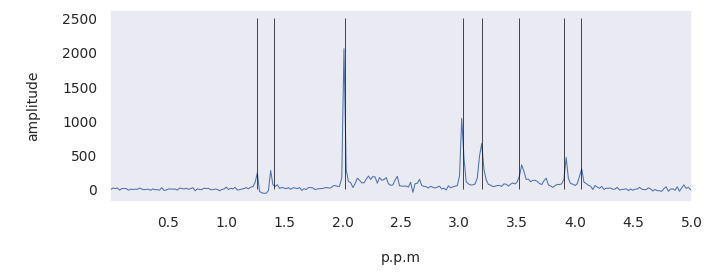

In [ ]:
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)

fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=(ppm + shift), y=data['spectrum'], size=0.85, legend=False)

handle.set_xticks(ticks=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

handle.vlines(x=[1.26492958, 1.4060342, 2.01848351, 3.03503396, 3.20090287,
                 3.51636055, 3.90135498, 4.05096051],
              ymin=0, ymax=2500, linewidth=0.5, color='#000000')

handle.set_xlabel('\np.p.m', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim(0, 5)

<br>
<br>

## FPT$^{-}$

In [ ]:
n_poles, n_multiplicities = ExFroissart(_numerator=n_numerator, _denominator=n_denominator)()


TYPES: <class 'numpy.ndarray'>, <class 'numpy.ndarray'>
2026-08-25 11:20:30.136


In [ ]:
n_derivations = Internal(_master=master, _poles=n_poles, _multiplicities=n_multiplicities, pade=-1)()

In [ ]:
n_derivations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 768 to 1020
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype     
---  ------        --------------  -----     
 0   pole          131 non-null    complex128
 1   multiplicity  131 non-null    int64     
 2   omega         131 non-null    complex128
 3   ppm           131 non-null    float64   
dtypes: complex128(2), float64(1), int64(1)
memory usage: 7.2 KB


In [ ]:
n_derivations['ppm'].values

array([0.01719625, 0.05838502, 0.09684553, 0.13231201, 0.16330266,
       0.20911176, 0.241544  , 0.27694944, 0.31931947, 0.36478486,
       0.39993653, 0.45837516, 0.44018632, 0.51493716, 0.56938834,
       0.51601263, 0.61790577, 0.65987739, 0.69431813, 0.73686945,
       0.77596389, 0.80113008, 0.84397131, 0.8845329 , 0.92023893,
       0.96184304, 1.00732781, 1.04364616, 1.08605063, 1.12754688,
       1.17639398, 1.22977073, 1.1678765 , 1.26722964, 1.3125935 ,
       1.36145343, 1.38545118, 1.4302277 , 1.47113878, 1.50670664,
       1.54301212, 1.58413109, 1.63791725, 1.68125052, 1.72028303,
       1.75232573, 1.7928333 , 1.83083205, 1.87444191, 1.91684291,
       1.95853982, 1.99190062, 2.02125911, 2.05831474, 2.10474566,
       2.15016388, 2.18466253, 2.25499153, 2.22151358, 2.296904  ,
       2.32900737, 2.36808522, 1.84459217, 2.41631313, 2.45555712,
       2.49248233, 2.52473277, 2.5657724 , 2.60721098, 2.64755673,
       2.68513074, 2.72673524, 2.7635589 , 2.80435077, 2.84585

(0.0, 5.0)

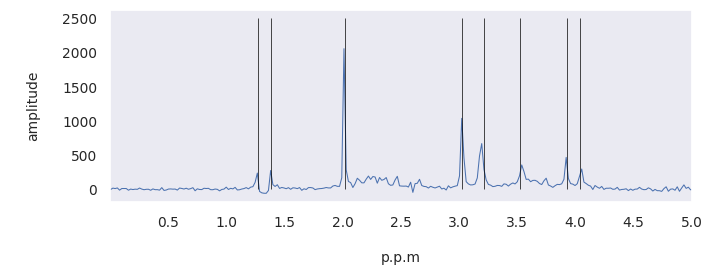

In [ ]:
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)

fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=(ppm + shift), y=data['spectrum'], size=0.85, legend=False)

handle.set_xticks(ticks=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

handle.vlines(x=[1.26722964, 1.38545118, 2.02125911, 3.02944519, 3.2163033,
                 3.52856816, 3.92849656, 4.04199182],
              ymin=0, ymax=2500, linewidth=0.5, color='#000000')

handle.set_xlabel('\np.p.m', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim(0, 5)

<br>
<br>
<br>

# Stability

* FPT$^{+}$: In side the unit circle
* FPT$^{-}$: Outwith the unit circle

<br>

## POLES$^{\pm}$: Initial

In [ ]:
system = pd.concat([n_derivations.assign(fpt=-1, control=np.imag(n_derivations['pole'])),
                    p_derivations.assign(fpt=1, control=-np.imag(p_derivations['pole']))],
                   ignore_index=True, axis=0)

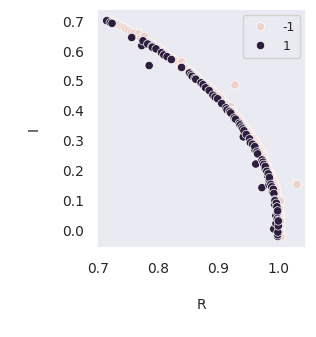

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The converging poles of each rational function

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)

fig = plt.figure(figsize=(2.7, 3.1))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.scatterplot(data=system, x=np.real(system['pole']), y=system['control'], hue='fpt', legend='auto')

handle.set_xlabel('\nR\n', fontdict={'fontsize': 10});
handle.set_ylabel('\nI\n', fontdict={'fontsize': 10});

handle.legend(loc='best', fontsize=9);
plt.show()


<br>
<br>

## POLES$^{\pm}$: Stable

**Numerics**

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Stability Class

class Stable:

    def __init__(self):
        pass

    def __distinct(self, left: np.ndarray, right: np.ndarray):

        # Hence
        matrix = np.subtract(left, np.conjugate(right.copy()))
        absolute = np.abs(matrix)
        indices = np.argmin(absolute, axis=1)
        differences = absolute[np.arange(indices.shape[0]), indices]

        instances = pd.DataFrame(data={'left': left.squeeze(), 'right': right.squeeze()[indices],
                                       'i': indices, 'difference':  differences})

        minima = instances.groupby(by=['i']).agg(difference=('difference', 'min'))

        distinct = instances.loc[instances['difference'].isin(minima['difference'].unique()), ['left', 'right']]

        return distinct

    def __call__(self, _n_derivations: pd.DataFrame, _p_derivations: pd.DataFrame):

        left = _n_derivations['pole'].values[:, np.newaxis]
        right = _p_derivations['pole'].values[np.newaxis, :]

        # distinct pairings
        distinct = self.__distinct(left=left, right=right)

        # Approaching stability
        n_stable = n_derivations.loc[n_derivations['pole'].isin(distinct['left'].values), :]
        p_stable = p_derivations.loc[p_derivations['pole'].isin(distinct['right'].values), :]

        return n_stable, p_stable


In [ ]:
stable = Stable()
n_stable, p_stable = stable(_n_derivations=n_derivations, _p_derivations=p_derivations)

<br>

Hence

In [ ]:
system = pd.concat([n_stable.assign(fpt=-1, control=np.imag(n_stable['pole'])),
                    p_stable.assign(fpt=1, control=np.imag(np.conjugate(p_stable['pole'])))],
                   ignore_index=True, axis=0)

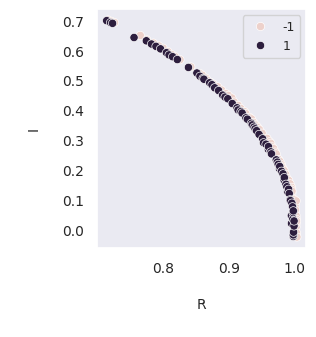

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The stable converging poles

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)

fig = plt.figure(figsize=(2.7, 3.1))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.scatterplot(data=system, x=np.real(system['pole']), y=system['control'], hue='fpt', legend='auto')

handle.set_xlabel('\nR\n', fontdict={'fontsize': 10});
handle.set_ylabel('\nI\n', fontdict={'fontsize': 10});

handle.legend(loc='best', fontsize=9);

<br>
<br>

# Complex Numerics

## FPT$^{-}$

### $\zeta^{^{-}}_{_{k, j_{k}}}$

In [ ]:
# @title {"vertical-output":true,"form-width":"225px","single-column":true}
# @markdown $\zeta^{^{-}}_{_{k, j_{k}}}$: A class for determining the amplitude/phase estimates $vis$-$\grave{a}$-$vis$
# @markdown (a) $k^{th}$ pole, and (b) $j^{th}$ multiplicity of $k^{th}$ pole

class EFPTN:

    def __init__(self, _numerator: np.ndarray, _denominator: np.ndarray) -> None:

        self.__numerator = _numerator
        self.__denominator = _denominator

    def __set_numerator(self, _attributes: pd.Series):

        length = self.__numerator.shape[0]
        exponents = np.linspace(start=0, stop=(-length + 1), num=length)
        variables = np.power(1/_attributes.pole, exponents)

        return np.dot(self.__numerator, variables)

    def __set_denominator(self, _attributes: pd.Series, derivative: int):

        # The derivative of a constant is zero, therefore exclude the coefficient c[0]
        sequence = self.__denominator[1:]

        # The negative exponents, and subsequently the non-linear variables
        length = sequence.shape[0]
        start = -(derivative + 1)
        exponents = np.linspace(start=start, stop=(start - length + 1), num=length)
        variables = np.power(1/_attributes.pole, exponents)

        # The factors
        factors = exponents + 1

        # Estimate
        return np.sum(factors * sequence * variables)

    def exc(self, _attributes: pd.Series):

        p = self.__set_numerator(_attributes=_attributes)

        vectors = []
        multiplicity = int(np.real(_attributes.multiplicity))
        for derivative in np.linspace(start=1, stop=multiplicity, num=multiplicity, dtype=int):
            q = self.__set_denominator(_attributes=_attributes, derivative=derivative)
            zeta = p/q
            vectors.append(
                {'pole': _attributes.pole, 'omega': _attributes.omega,
                 'ppm': np.real(_attributes.ppm), 'derivative': derivative,
                 'zeta': zeta, 'fpt': -1})

        return vectors


In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Hence

__efptn = dask.delayed(EFPTN(_numerator=n_numerator, _denominator=n_denominator).exc)

computations = []
for i, attributes in n_stable.iterrows():
    efptn = __efptn(_attributes=attributes)
    computations.append(efptn)

calculations = dask.compute(computations, scheduler='threads')[0]
n_intensities = pd.DataFrame.from_dict(sum(calculations, []))

In [ ]:
n_intensities.head()

,pole,omega,ppm,derivative,zeta,fpt
0,0.717114+0.700963j,-1935.023817+ 6.982491j,0.017196,1,0.077663-0.095612j,-1
1,0.721975+0.696441j,-1918.494472+ 7.822904j,0.058385,1,0.093786-0.140690j,-1
2,0.726768+0.692453j,-1903.060000+ 9.567296j,0.096846,1,0.093449-0.012638j,-1
3,0.765877+0.649278j,-1757.975613+ 10.120500j,0.458375,1,-0.676171+0.438610j,-1
4,0.775828+0.634303j,-1713.425239+ 5.300279j,0.569388,1,-0.062264+0.016618j,-1


<br>

### $c^{-}_{t}$

Select a decomposition

In [ ]:
T = n_intensities.iloc[23].squeeze()
logger.info(T)


pole             0.904857+   0.439679j
omega        -1130.779273+  15.014221j
ppm              2.021259+   0.000000j
derivative       1.000000+   0.000000j
zeta           -29.398774-  55.743878j
fpt             -1.000000+   0.000000j
Name: 23, dtype: complex128
2026-08-25 11:21:38.215


<br>

Estimates

In [ ]:
logger.info('phase: %s\namplitude: %s\nfrequency: %s or %s p.p.m.\ndecay: %s\n',
            np.angle(T.zeta), np.abs(T.zeta),
            np.real(T.omega), shift + np.real(T.omega)/(2*np.pi*magnet),
            np.imag(T.omega))


phase: -2.056115225099404
amplitude: 63.02116962347891
frequency: -1130.779273040731 or 2.0212591067748193 p.p.m.
decay: 15.01422108280941

2026-08-25 11:21:40.433


<br>

Determine the time series values $c^{-}_{t}$.  For each set of estimates

* If the phase angle $\phi = ∠\{\zeta^{^{-}}_{_{k, j_{k}}}\}$ (radians), then the shift per time point is $ \phi  T_{_{N \times 1}}$; $T_{_{N \times 1}}$ denotes the $N$ time points of a series in question.
* The unit of measure of $np.angle(\zeta^{^{-}}_{_{k, j_{k}}})$ is radians.

In [ ]:
angular = (times * T.omega) - (times * np.angle(T.zeta) * magnet)
curve = np.abs(T.zeta) * np.power(times, T.derivative.real - 1) * np.exp(1j * angular)

<br>

Illustrate

(-0.01, 0.1)

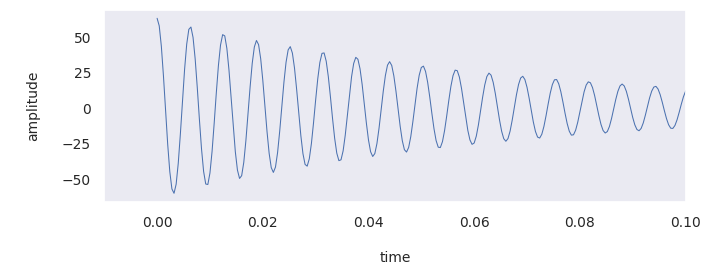

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Series

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)


fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=times, y=np.real(curve), size=0.85, legend=False)

handle.set_xlabel('\ntime', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim((-0.01, 0.1))

<br>
<br>

### spectrum: parametric method

Ascertain
* curve &Rarr; $1$ x $N_{curve}$
* matrix &Rarr; $N_{times}$ x $N_{frequencies}$

noting that
* $N_{curve}$ = $N_{times}$, &nbsp; <b>always</b>

The spectrum has a value per frequency point; each frequency point value is a quantity across time.
* spectrum: curve x matrix &Rarr; $1$ x $N_{frequencies}$

<br>

Illustrate; remember to shift the spectrum, if the series has a shift value.z

<br>

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Algorithm

frequencies = -2 * np.pi * np.linspace(start=-1/(2 * tau), stop=1/(2 * tau), num=2*steps)
parts = (frequencies + np.angle(T.zeta)*magnet)/(2 * np.pi * magnet )
matrix = np.multiply(times[:,np.newaxis], frequencies[np.newaxis,:])
spectrum = np.dot(curve[np.newaxis,:], np.exp(-1j*matrix)) / (2 * np.pi)

logger.info('curve: %s\ntimes: %s\nfrequencies: %s\nparts per million(p.p.m.): %s\nmatrix: %s\nspectrum: %s\n',
            curve.shape, times.shape, frequencies.shape, parts.shape, matrix.shape, spectrum.shape)


curve: (2048,)
times: (2048,)
frequencies: (4096,)
parts per million(p.p.m.): (4096,)
matrix: (2048, 4096)
spectrum: (1, 4096)

2026-08-25 11:22:18.845


(0.0, 5.0)

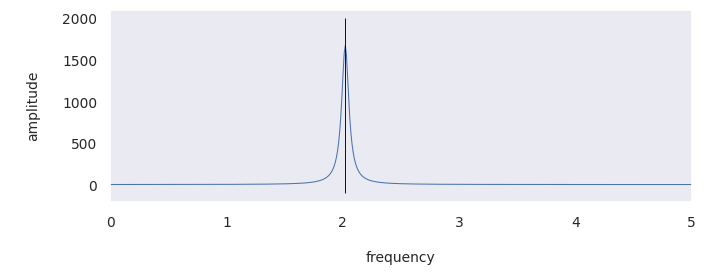

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The Spectrum

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)


fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=shift + parts, y=np.real(spectrum.squeeze()), size=0.85, legend=False)

handle.vlines(x=[np.real(T.ppm)], ymin=-100, ymax=2000, linewidth=0.65, color='black')

handle.set_xlabel('\nfrequency', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim((0, 5))


<br>
<br>

### spectrum: non-parametric

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Algorithm

__frequencies = frequencies + (magnet * np.angle(T.zeta))
__parts = __frequencies/(2 * np.pi * magnet )

reference = np.exp(-1j * __frequencies * tau)
quotient = (np.abs(T.zeta) * reference) / np.power(reference - T.pole, T.derivative.real) / (-2 * np.pi)

(0.0, 5.0)

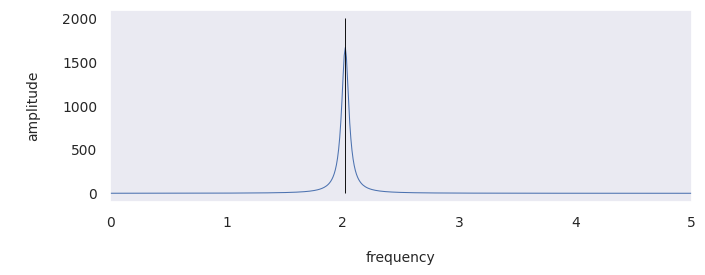

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The Spectrum

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)


fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=shift + __parts, y=np.real(quotient), size=0.85, legend=False)

handle.vlines(x=[np.real(T.ppm)], ymin=-5, ymax=2000, linewidth=0.65, color='black')

handle.set_xlabel('\nfrequency', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim((0, 5))


<br>
<br>
<br>

## FPT$^{+}$

The poles of FPT$^{+}$ converge much more slowly than the FPT$^{-}$, therefore it is sometimes impossible to exploit the internal validation option, i.e., the option of comparing the estimates due to the complementary rational functions.   Affecting factors include (a) signal length, (b) signal-to-noise ratio, or rather the number of signal averages used for signal acquistion, (c) and more.

### $\zeta^{^{+}}_{_{k, j_{k}}}$

In [ ]:
# @title {"vertical-output":true,"form-width":"225px","single-column":true}
# @markdown $\zeta^{+}_{_{k, j_{k}}}$: A class for determining the amplitude/phase estimates $vis$-$\grave{a}$-$vis$
# @markdown (a) $k^{th}$ pole, and (b) $j^{th}$ multiplicity of $k^{th}$ pole

class EFPTP:

    def __init__(self, _numerator: np.ndarray, _denominator: np.ndarray) -> None:

        self.__numerator = _numerator
        self.__denominator = _denominator

    def __set_numerator(self, _attributes: pd.Series):

        length = self.__numerator.shape[0]
        exponents = np.linspace(start=0, stop=(length - 1), num=length)
        variables = np.power(_attributes.pole, exponents)

        return np.dot(self.__numerator, variables)

    def __set_denominator(self, _attributes: pd.Series, derivative: int):

        # derivative
        # __sequence = np.polynomial.polynomial.Polynomial(coef=self.__denominator)
        # sequence = __sequence.deriv(m=derivative)
        # coefficients = sequence.coef
        coefficients = np.polynomial.polynomial.polyder(c=self.__denominator, m=derivative)

        # variables
        exponents = np.linspace(start=0, stop=(coefficients.shape[0] - 1), num=coefficients.shape[0])
        variables = np.power(_attributes.pole, exponents)

        # estimate
        return np.dot(coefficients, variables)

    def exc(self, _attributes: pd.Series):

        p = self.__set_numerator(_attributes=_attributes)

        vectors = []
        multiplicity = int(np.real(_attributes.multiplicity))
        for derivative in np.linspace(start=1, stop=multiplicity, num=multiplicity, dtype=int):
            q = self.__set_denominator(_attributes=_attributes, derivative=derivative)
            zeta = p/q
            vectors.append(
                {'pole': _attributes.pole, 'omega': _attributes.omega,
                 'ppm': np.real(_attributes.ppm), 'derivative': derivative,
                 'zeta': zeta, 'fpt': 1})

        return vectors


In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Hence

__efptp = dask.delayed(EFPTP(_numerator=p_numerator, _denominator=p_denominator).exc)

computations = []
for i, attributes in p_stable.iterrows():
    efptp = __efptp(_attributes=attributes)
    computations.append(efptp)

calculations = dask.compute(computations, scheduler='threads')[0]
p_intensities = pd.DataFrame.from_dict(sum(calculations, []))

In [ ]:
p_intensities.head()

<br>
<br>

### $c^{+}_{t}$

Select a decomposition

In [ ]:
T = p_intensities.iloc[23].squeeze()
logger.info(T)

<br>

Estimates

In [ ]:
logger.info('phase: %s\namplitude: %s\nfrequency: %s or %s p.p.m.\ndecay: %s\n',
            np.angle(T.zeta), np.abs(T.zeta),
            np.real(T.omega), shift + np.real(T.omega)/(2*np.pi*magnet),
            np.imag(T.omega))

<br>

Curve

In [ ]:
angular = (T.omega * times) - (magnet * np.angle(T.zeta) * times)
curve = np.abs(T.zeta) * np.power(times, T.derivative.real - 1) * np.exp(1j * angular)

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Series

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)


fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=times, y=np.real(curve), size=0.85, legend=False)

handle.set_xlabel('\ntime', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim((-0.01, 0.2))

<br>

### spectrum: parametric

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Algorithm

frequencies = -2 * np.pi * np.linspace(start=-1/(2 * tau), stop=1/(2 * tau), num=steps)
parts = ( frequencies + magnet * np.angle(T.zeta) ) /(2 * np.pi * magnet )
matrix = np.multiply(times[:,np.newaxis], frequencies[np.newaxis,:])
spectrum = np.dot(curve[np.newaxis,:], np.exp(-1j*matrix)) / (2 * np.pi)

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The Spectrum

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)

fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=shift + parts, y=np.real(spectrum.squeeze()), size=0.85, legend=False)

handle.vlines(x=[np.real(T.ppm)], ymin=-5, ymax=5, linewidth=0.65, color='black')

handle.set_xlabel('\nfrequency', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim((0, 5))

<br>
<br>

### spectrum: non-parametric

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown Algorithm

__frequencies = frequencies + (magnet * np.angle(T.zeta))
__parts = __frequencies/(2 * np.pi * magnet )

reference = np.exp(1j * __frequencies * tau)
quotient = (np.abs(T.zeta) * reference) / np.power(reference - T.pole, T.derivative.real) / (2 * np.pi)

In [ ]:
# @title {"vertical-output":true,"single-column":true,"display-mode":"form"}
# @markdown The Spectrum

plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)

fig = plt.figure(figsize=(7.5, 2.5))
handle = fig.gca()
handle.tick_params(axis='both', labelsize='small')
handle.tick_params(axis='x', rotation=0)

sns.lineplot(x=shift + __parts, y=np.real(quotient), size=0.85, legend=False)

handle.vlines(x=[np.real(T.ppm)], ymin=-5, ymax=5, linewidth=0.65, color='black')

handle.set_xlabel('\nfrequency', fontdict={'fontsize': 10});
handle.set_ylabel('\namplitude\n', fontdict={'fontsize': 10});

handle.set_xlim((0, 5))
